In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Groceries_dataset.csv to Groceries_dataset (1).csv


In [ ]:
df = pd.read_csv("Groceries_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (38765, 3)


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [ ]:
# Basic dataset information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Customers:", df["Member_number"].nunique())
print("Unique Products:", df["itemDescription"].nunique())
print("Unique Dates:", df["Date"].nunique())

Dataset Shape: (38765, 3)

Column Names:
['Member_number', 'Date', 'itemDescription']

Data Types:
Member_number       int64
Date               object
itemDescription    object
dtype: object

Missing Values:
Member_number      0
Date               0
itemDescription    0
dtype: int64

Duplicate Rows: 759

Unique Customers: 3898
Unique Products: 167
Unique Dates: 728


In [ ]:
# Convert date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# Remove rows with missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Clean product names
df["itemDescription"] = df["itemDescription"].str.strip().str.lower()

print("Cleaned Dataset Shape:", df.shape)
print("\nRemaining Missing Values:")
print(df.isnull().sum())

df.head()

Cleaned Dataset Shape: (38006, 3)

Remaining Missing Values:
Member_number      0
Date               0
itemDescription    0
dtype: int64


,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


In [ ]:
print("===== DATASET SUMMARY =====")

print("Total purchase records:", len(df))
print("Unique customers:", df["Member_number"].nunique())
print("Unique products:", df["itemDescription"].nunique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

print("\n===== TOP 15 PRODUCTS =====")
top_products = df["itemDescription"].value_counts().head(15)
print(top_products)

print("\n===== PURCHASES PER CUSTOMER =====")
customer_purchases = df.groupby("Member_number").size()

print("Average purchases per customer:", round(customer_purchases.mean(), 2))
print("Maximum purchases by one customer:", customer_purchases.max())

===== DATASET SUMMARY =====
Total purchase records: 38006
Unique customers: 3898
Unique products: 167
Date range: 2014-01-01 to 2015-12-30

===== TOP 15 PRODUCTS =====
itemDescription
whole milk          2363
other vegetables    1827
rolls/buns          1646
soda                1453
yogurt              1285
root vegetables     1041
tropical fruit      1014
bottled water        908
sausage              903
citrus fruit         795
pastry               774
pip fruit            734
shopping bags        712
canned beer          702
bottled beer         678
Name: count, dtype: int64

===== PURCHASES PER CUSTOMER =====
Average purchases per customer: 9.75
Maximum purchases by one customer: 35


**Visualization 1: Top 15 Products**

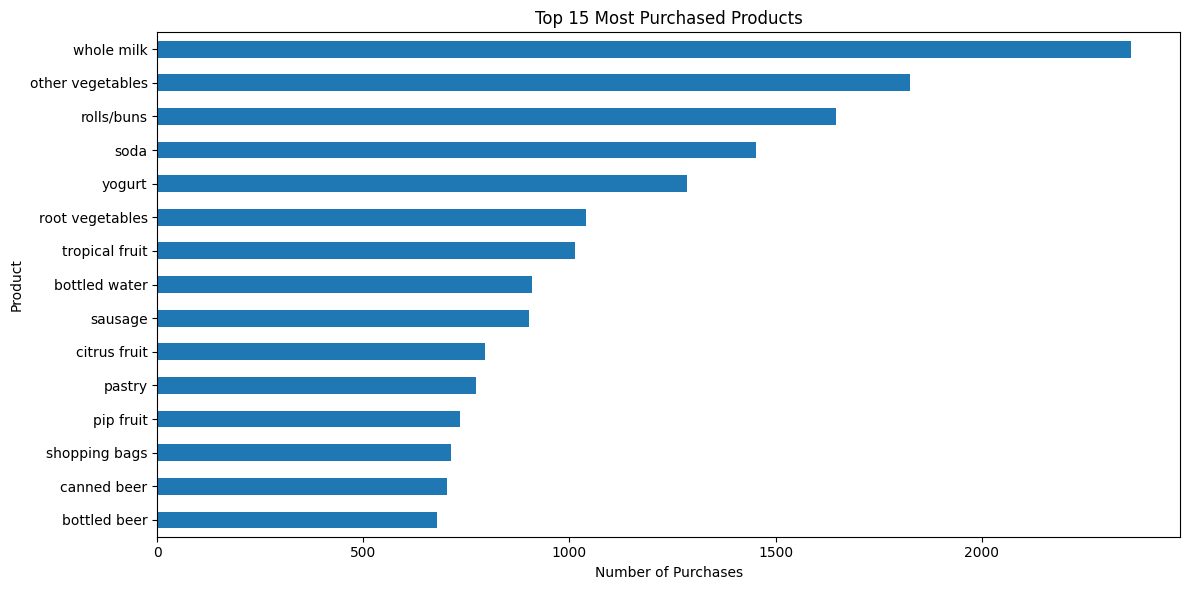

In [ ]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 15 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

**Top Product Categories**

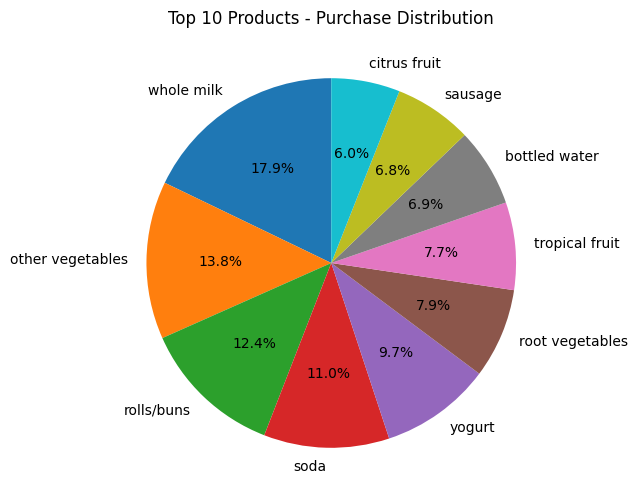

In [ ]:
product_counts = df["itemDescription"].value_counts()

plt.figure(figsize=(10, 6))

product_counts.head(10).plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Products - Purchase Distribution")
plt.ylabel("")

plt.show()

In [ ]:
# Create a unique transaction ID using customer + date
df["Transaction_ID"] = (
    df["Member_number"].astype(str) + "_" +
    df["Date"].dt.strftime("%Y-%m-%d")
)

print("Unique transactions:", df["Transaction_ID"].nunique())
print("Unique products:", df["itemDescription"].nunique())

# Show example baskets
basket_example = df.groupby("Transaction_ID")["itemDescription"].apply(list)

print("\nExample shopping baskets:")
for transaction, products in basket_example.head(10).items():
    print(transaction, "->", products)

Unique transactions: 14963
Unique products: 167

Example shopping baskets:
1000_2014-06-24 -> ['whole milk', 'pastry', 'salty snack']
1000_2015-03-15 -> ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
1000_2015-05-27 -> ['soda', 'pickled vegetables']
1000_2015-07-24 -> ['canned beer', 'misc. beverages']
1000_2015-11-25 -> ['sausage', 'hygiene articles']
1001_2014-02-07 -> ['sausage', 'whole milk', 'rolls/buns']
1001_2014-12-12 -> ['whole milk', 'soda']
1001_2015-01-20 -> ['frankfurter', 'soda', 'whipped/sour cream']
1001_2015-04-14 -> ['beef', 'white bread']
1001_2015-05-02 -> ['frankfurter', 'curd']


In [ ]:
!pip install mlxtend -q

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Convert each transaction into a list of products
transactions = df.groupby("Transaction_ID")["itemDescription"].apply(list).tolist()

print("Total shopping baskets:", len(transactions))
print("First basket:", transactions[0])

# Convert transactions into one-hot encoded format
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("\nBasket matrix shape:", basket.shape)
basket.head()

Total shopping baskets: 14963
First basket: ['whole milk', 'pastry', 'salty snack']

Basket matrix shape: (14963, 167)


,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,...,uht-milk,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets["item_count"] = frequent_itemsets["itemsets"].apply(len)

print("Number of frequent itemsets:", len(frequent_itemsets))

frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(20)

Number of frequent itemsets: 69


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets,item_count
62,0.157923,(whole milk),1
39,0.122101,(other vegetables),1
45,0.110005,(rolls/buns),1
51,0.097106,(soda),1
63,0.085879,(yogurt),1
46,0.069572,(root vegetables),1
56,0.067767,(tropical fruit),1
4,0.060683,(bottled water),1
48,0.060349,(sausage),1
14,0.053131,(citrus fruit),1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.10
)

rules = rules.sort_values(
    "lift",
    ascending=False
)

print("Number of association rules:", len(rules))

rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

Number of association rules: 4


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
3,(yogurt),(whole milk),0.011161,0.129961,0.822940
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
2,(soda),(whole milk),0.011629,0.119752,0.758296


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
positive_rules = rules[rules["lift"] > 1].copy()

print("Rules with lift > 1:", len(positive_rules))

display(
    positive_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

Rules with lift > 1: 0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# Generate frequent itemsets with a balanced support threshold
frequent_itemsets = apriori(
    basket,
    min_support=0.002,
    use_colnames=True
)

frequent_itemsets["item_count"] = frequent_itemsets["itemsets"].apply(len)

print("Total frequent itemsets:", len(frequent_itemsets))

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.05
)

# Keep only positive associations
positive_rules = rules[
    rules["lift"] > 1
].copy()

positive_rules = positive_rules.sort_values(
    "lift",
    ascending=False
)

print("Total association rules:", len(rules))
print("Rules with lift > 1:", len(positive_rules))

display(
    positive_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Total frequent itemsets: 330
Total association rules: 219
Rules with lift > 1: 24


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
73,(curd),(sausage),0.002941,0.087302,1.446615
28,(brown bread),(canned beer),0.002406,0.063943,1.362937
29,(canned beer),(brown bread),0.002406,0.051282,1.362937
97,(frozen vegetables),(sausage),0.002072,0.073986,1.225966
10,(sausage),(bottled beer),0.003342,0.055371,1.222000
9,(bottled beer),(sausage),0.003342,0.073746,1.222000
87,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
193,(yogurt),(sausage),0.005748,0.066926,1.108986
194,(sausage),(yogurt),0.005748,0.095238,1.108986
96,(frozen vegetables),(root vegetables),0.002139,0.076372,1.097751


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

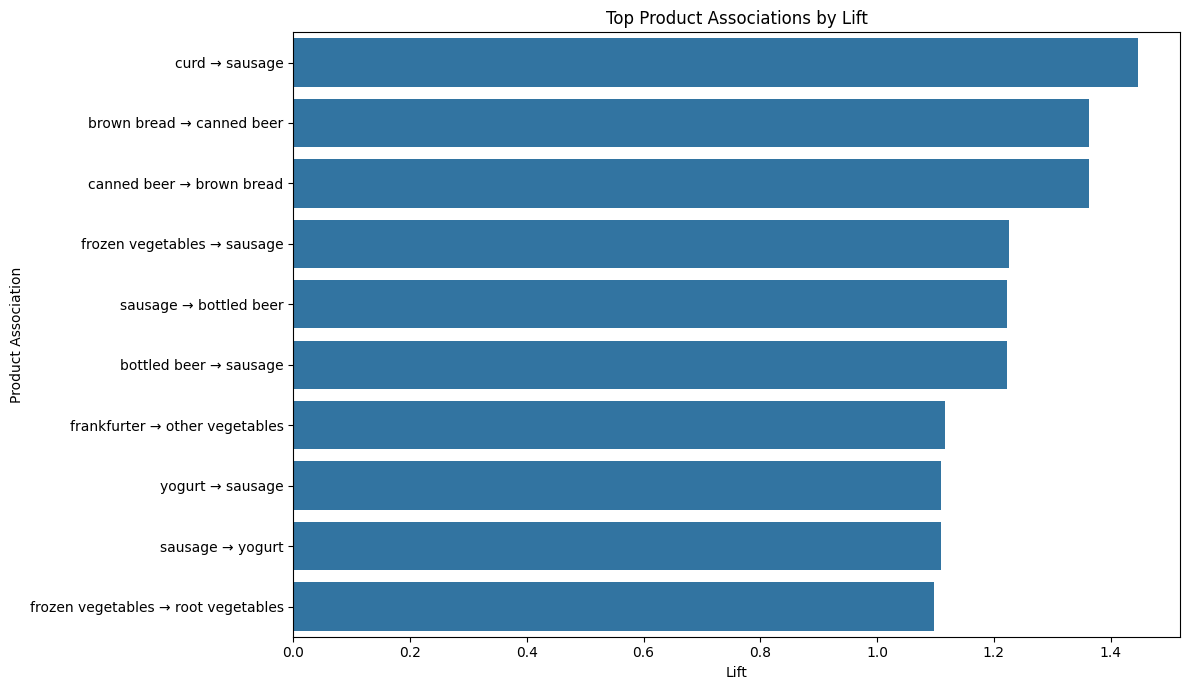

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# Prepare top association rules for visualization
plot_rules = positive_rules.head(10).copy()

plot_rules["rule"] = (
    plot_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
    + " → " +
    plot_rules["consequents"].apply(lambda x: ", ".join(list(x)))
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_rules,
    x="lift",
    y="rule"
)

plt.title("Top Product Associations by Lift")
plt.xlabel("Lift")
plt.ylabel("Product Association")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

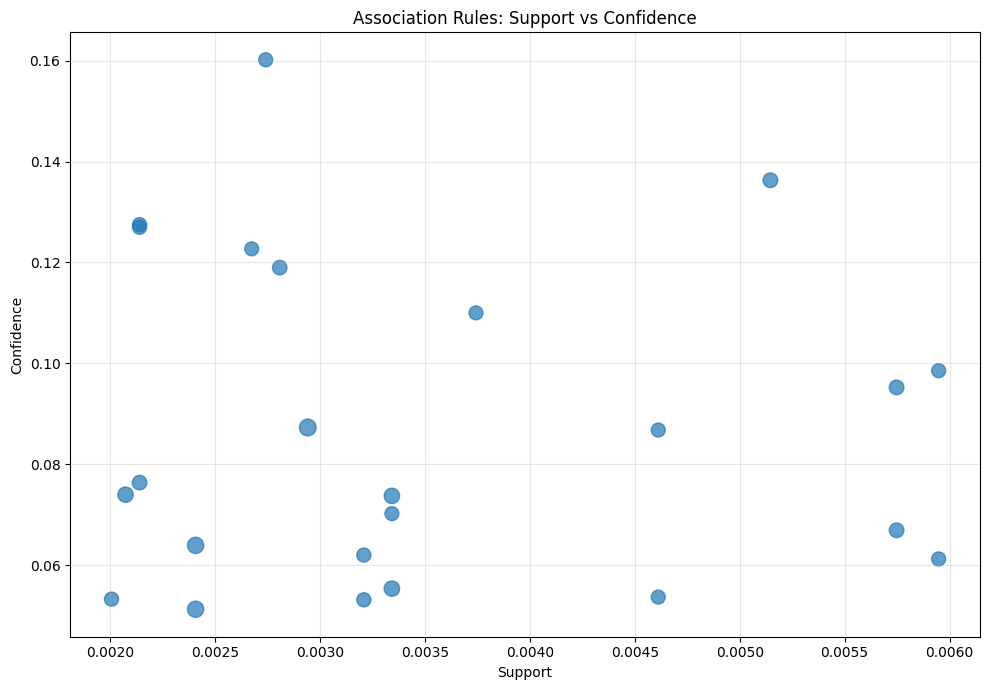

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    positive_rules["support"],
    positive_rules["confidence"],
    s=positive_rules["lift"] * 100,
    alpha=0.7
)

plt.title("Association Rules: Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Prepare KNN dataset**

In [ ]:
# Target product
target_product = "whole milk"

# Use the most frequently purchased 20 products as features
top_20_products = (
    df["itemDescription"]
    .value_counts()
    .head(20)
    .index
    .tolist()
)

# Make sure target is included
if target_product not in top_20_products:
    top_20_products.append(target_product)

knn_data = basket[
    [p for p in top_20_products if p in basket.columns]
].copy()

# Target: whether whole milk was purchased
y = knn_data[target_product].astype(int)

# Features: all selected products except whole milk
X = knn_data.drop(columns=[target_product])

print("KNN feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

KNN feature shape: (14963, 19)
Target distribution:
whole milk
0    12600
1     2363
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Train KNN**

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

print("KNN model trained successfully!")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

KNN model trained successfully!


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("===== KNN MODEL EVALUATION =====")
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

===== KNN MODEL EVALUATION =====
Accuracy: 0.8109

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2520
           1       0.16      0.05      0.07       473

    accuracy                           0.81      2993
   macro avg       0.50      0.50      0.48      2993
weighted avg       0.73      0.81      0.76      2993


Confusion Matrix:
[[2405  115]
 [ 451   22]]


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

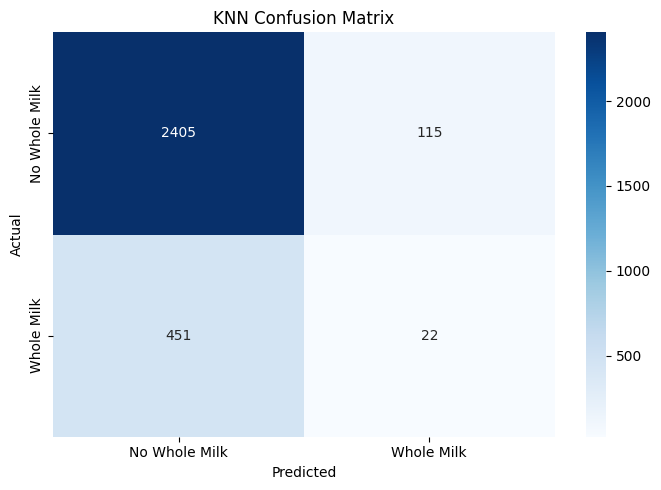

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Whole Milk", "Whole Milk"],
    yticklabels=["No Whole Milk", "Whole Milk"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
print("===== FINAL KNN RESULTS =====")

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

===== FINAL KNN RESULTS =====
Accuracy: 0.8109

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2520
           1       0.16      0.05      0.07       473

    accuracy                           0.81      2993
   macro avg       0.50      0.50      0.48      2993
weighted avg       0.73      0.81      0.76      2993


Confusion Matrix:
[[2405  115]
 [ 451   22]]


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
!pip install gradio plotly -q

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is

In [1]:
import gradio
import plotly

print("Gradio version:", gradio.__version__)
print("Plotly version:", plotly.__version__)
print("Dashboard libraries are ready!")

Gradio version: 6.26.0
Plotly version: 5.24.1
Dashboard libraries are ready!


In [3]:
import os
import pandas as pd
import numpy as np

# Find CSV files in Colab
csv_files = [f for f in os.listdir("/content") if f.lower().endswith(".csv")]

print("CSV files found:", csv_files)

if len(csv_files) == 0:
    print("\nNo CSV found.")
    print("Please upload Groceries_dataset.csv using the upload button.")
else:
    print("\nUsing:", csv_files[0])

    df = pd.read_csv("/content/" + csv_files[0])

    print("\nDataset loaded!")
    print("Shape:", df.shape)
    display(df.head())

CSV files found: ['Groceries_dataset.csv', 'Groceries_dataset (1).csv']

Using: Groceries_dataset.csv

Dataset loaded!
Shape: (38765, 3)


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [4]:
# ============================================
# RECREATE COMPLETE ANALYSIS
# ============================================

import pandas as pd
import numpy as np

# ----------------------------
# CLEAN DATA
# ----------------------------

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

df = df.dropna()
df = df.drop_duplicates()

df["itemDescription"] = (
    df["itemDescription"]
    .str.strip()
    .str.lower()
)

# ----------------------------
# CREATE TRANSACTION ID
# ----------------------------

df["Transaction_ID"] = (
    df["Member_number"].astype(str)
    + "_"
    + df["Date"].dt.strftime("%Y-%m-%d")
)

print("Clean dataset:", df.shape)
print("Customers:", df["Member_number"].nunique())
print("Products:", df["itemDescription"].nunique())
print("Transactions:", df["Transaction_ID"].nunique())

# ----------------------------
# CREATE BASKETS
# ----------------------------

transactions = (
    df.groupby("Transaction_ID")["itemDescription"]
    .apply(list)
    .tolist()
)

# ----------------------------
# BASKET MATRIX
# ----------------------------

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("Basket shape:", basket.shape)

# ----------------------------
# APRIORI
# ----------------------------

from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.002,
    use_colnames=True
)

frequent_itemsets["item_count"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

# ----------------------------
# ASSOCIATION RULES
# ----------------------------

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.05
)

# Positive associations
positive_rules = rules[
    rules["lift"] > 1
].copy()

positive_rules = positive_rules.sort_values(
    "lift",
    ascending=False
)

print("Frequent itemsets:", len(frequent_itemsets))
print("Association rules:", len(rules))
print("Positive rules:", len(positive_rules))

display(
    positive_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

# ----------------------------
# KNN
# ----------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

target_product = "whole milk"

top_20_products = (
    df["itemDescription"]
    .value_counts()
    .head(20)
    .index
    .tolist()
)

if target_product not in top_20_products:
    top_20_products.append(target_product)

knn_data = basket[
    [p for p in top_20_products if p in basket.columns]
].copy()

y = knn_data[target_product].astype(int)

X = knn_data.drop(
    columns=[target_product]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

y_pred = knn.predict(
    X_test_scaled
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========== KNN ==========")
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n========== ANALYSIS READY ==========")

Clean dataset: (38006, 4)
Customers: 3898
Products: 167
Transactions: 14963
Basket shape: (14963, 167)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Frequent itemsets: 330
Association rules: 219
Positive rules: 24


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
73,(curd),(sausage),0.002941,0.087302,1.446615
28,(brown bread),(canned beer),0.002406,0.063943,1.362937
29,(canned beer),(brown bread),0.002406,0.051282,1.362937
97,(frozen vegetables),(sausage),0.002072,0.073986,1.225966
10,(sausage),(bottled beer),0.003342,0.055371,1.222000
9,(bottled beer),(sausage),0.003342,0.073746,1.222000
87,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
193,(yogurt),(sausage),0.005748,0.066926,1.108986
194,(sausage),(yogurt),0.005748,0.095238,1.108986
96,(frozen vegetables),(root vegetables),0.002139,0.076372,1.097751


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


========== KNN ==========
Accuracy: 0.8109

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2520
           1       0.16      0.05      0.07       473

    accuracy                           0.81      2993
   macro avg       0.50      0.50      0.48      2993
weighted avg       0.73      0.81      0.76      2993


Confusion Matrix:
[[2405  115]
 [ 451   22]]

========== ANALYSIS READY ==========


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [5]:
print("df:", df.shape)
print("basket:", basket.shape)
print("positive_rules:", len(positive_rules))
print("KNN accuracy:", accuracy)

df: (38006, 4)
basket: (14963, 167)
positive_rules: 24
KNN accuracy: 0.810892081523555


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [6]:
import gradio as gr
import plotly.express as px

# =========================
# PREPARE DATA
# =========================

# Top 10 products
top_products = (
    df["itemDescription"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_products.columns = ["Product", "Purchases"]


# Association rules
dashboard_rules = positive_rules.copy()

dashboard_rules["Product A"] = dashboard_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

dashboard_rules["Product B"] = dashboard_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

dashboard_rules["Rule"] = (
    dashboard_rules["Product A"] +
    " → " +
    dashboard_rules["Product B"]
)

dashboard_rules = dashboard_rules.sort_values(
    "lift",
    ascending=False
)


# =========================
# CHART 1
# =========================

fig_products = px.bar(
    top_products.sort_values("Purchases"),
    x="Purchases",
    y="Product",
    orientation="h",
    title="Top 10 Most Purchased Products",
    template="plotly_white"
)

# =========================
# CHART 2
# =========================

top_rules = dashboard_rules.head(10)

fig_lift = px.bar(
    top_rules.sort_values("lift"),
    x="lift",
    y="Rule",
    orientation="h",
    title="Top Product Associations by Lift",
    template="plotly_white"
)

# =========================
# CHART 3
# =========================

fig_scatter = px.scatter(
    dashboard_rules,
    x="support",
    y="confidence",
    size="lift",
    hover_name="Rule",
    title="Support vs Confidence",
    template="plotly_white"
)


# =========================
# CSS
# =========================

css = """
body {
    background: #f5f7fb;
}

.title {
    text-align: center;
    font-size: 32px;
    font-weight: bold;
}

.subtitle {
    text-align: center;
    color: #666;
    margin-bottom: 25px;
}

.kpi {
    background: white;
    padding: 18px;
    border-radius: 12px;
    text-align: center;
    border: 1px solid #ddd;
}

.number {
    font-size: 27px;
    font-weight: bold;
}

.label {
    color: #666;
}

.card {
    background: white;
    padding: 20px;
    border-radius: 12px;
    border: 1px solid #ddd;
}

.bundle {
    background: white;
    padding: 20px;
    border-radius: 12px;
    border: 1px solid #ddd;
    min-height: 130px;
}
"""


# =========================
# DASHBOARD
# =========================

with gr.Blocks(
    title="Retail Market Basket Analytics",
    css=css
) as app:

    gr.HTML("""
    <div class="title">
        🛒 Retail Market Basket Analytics
    </div>

    <div class="subtitle">
        Data Science Hackathon | Grocery Purchase Analysis
    </div>
    """)

    # =====================
    # KPI
    # =====================

    with gr.Row():

        gr.HTML(f"""
        <div class="kpi">
            <div class="number">{len(df):,}</div>
            <div class="label">Purchase Records</div>
        </div>
        """)

        gr.HTML(f"""
        <div class="kpi">
            <div class="number">{df['Transaction_ID'].nunique():,}</div>
            <div class="label">Shopping Baskets</div>
        </div>
        """)

        gr.HTML(f"""
        <div class="kpi">
            <div class="number">{df['Member_number'].nunique():,}</div>
            <div class="label">Customers</div>
        </div>
        """)

        gr.HTML(f"""
        <div class="kpi">
            <div class="number">{df['itemDescription'].nunique():,}</div>
            <div class="label">Products</div>
        </div>
        """)

        gr.HTML(f"""
        <div class="kpi">
            <div class="number">{len(positive_rules)}</div>
            <div class="label">Positive Rules</div>
        </div>
        """)

    # =====================
    # PRODUCT ANALYSIS
    # =====================

    gr.Markdown("## 📊 Product Analysis")

    with gr.Row():
        gr.Plot(fig_products)
        gr.Plot(fig_lift)

    # =====================
    # ASSOCIATION ANALYSIS
    # =====================

    gr.Markdown("## 🔗 Market Basket Analysis")

    gr.Plot(fig_scatter)

    gr.Markdown("### Top Association Rules")

    table = dashboard_rules[
        [
            "Product A",
            "Product B",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20).copy()

    table.columns = [
        "Product A",
        "Product B",
        "Support",
        "Confidence",
        "Lift"
    ]

    gr.Dataframe(
        value=table,
        interactive=False
    )

    # =====================
    # BUNDLES
    # =====================

    gr.Markdown("## 🧺 Recommended Product Bundles")

    with gr.Row():

        gr.HTML("""
        <div class="bundle">
            <h3>🥛 Bundle 1</h3>
            <h2>Curd + Sausage</h2>
            <p><b>Lift:</b> 1.447</p>
        </div>
        """)

        gr.HTML("""
        <div class="bundle">
            <h3>🍞 Bundle 2</h3>
            <h2>Brown Bread + Canned Beer</h2>
            <p><b>Lift:</b> 1.363</p>
        </div>
        """)

        gr.HTML("""
        <div class="bundle">
            <h3>🥦 Bundle 3</h3>
            <h2>Frozen Vegetables + Sausage</h2>
            <p><b>Lift:</b> 1.226</p>
        </div>
        """)

    # =====================
    # BUSINESS
    # =====================

    gr.Markdown("## 🏪 Business Recommendations")

    with gr.Row():

        gr.HTML("""
        <div class="card">
            <h3>📍 Shelf Placement</h3>
            <ul>
                <li>Place positively associated products nearby.</li>
                <li>Create cross-category displays.</li>
                <li>Use high-lift products for cross-selling.</li>
            </ul>
        </div>
        """)

        gr.HTML("""
        <div class="card">
            <h3>🎯 Marketing</h3>
            <ul>
                <li>Create association-based bundles.</li>
                <li>Recommend associated products.</li>
                <li>Monitor popularity separately from lift.</li>
            </ul>
        </div>
        """)

    # =====================
    # KNN
    # =====================

    gr.Markdown("## 🤖 KNN Model Evaluation")

    with gr.Row():

        gr.HTML("""
        <div class="kpi">
            <div class="number">81.09%</div>
            <div class="label">Accuracy</div>
        </div>
        """)

        gr.HTML("""
        <div class="kpi">
            <div class="number">5%</div>
            <div class="label">Whole Milk Recall</div>
        </div>
        """)

        gr.HTML("""
        <div class="kpi">
            <div class="number">0.07</div>
            <div class="label">Whole Milk F1</div>
        </div>
        """)

    gr.Markdown("""
    **KNN Interpretation:** The model achieved 81.09% overall accuracy.
    The whole-milk class had low recall, so accuracy should be interpreted
    together with precision, recall and F1-score.
    """)

    # =====================
    # INSIGHTS
    # =====================

    gr.Markdown("## 💡 Key Insights")

    gr.Markdown("""
    **1.** Whole milk is the most frequently purchased product.

    **2.** Product popularity does not necessarily indicate strong association.

    **3.** Curd → Sausage has the highest observed lift of **1.447**.

    **4.** Brown Bread → Canned Beer has a lift of **1.363**.

    **5.** Frozen Vegetables → Sausage has a lift of **1.226**.

    **6.** There are **24 positive association rules** with lift greater than 1.

    **7.** KNN achieved **81.09% accuracy**, while whole-milk recall was **5%**.
    """)


# =========================
# LAUNCH
# =========================

app.launch(
    share=True,
    debug=False
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

* Running on public URL: https://c7fa1e9f5a0227d7e5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [8]:
# Stop any old Gradio server
try:
    app.close()
except:
    pass

# Launch a fresh public link
app.launch(
    share=True,
    debug=False
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Closing server running on port: 7860


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c7fa1e9f5a0227d7e5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

